# Case Olist — Notebook 02: Análise Exploratória com 3 Hipóteses Testadas

**Aluna:** Gabriela Piccinini  
**Curso:** MBA em Gestão Estratégica, Excelência Operacional e Métodos Ágeis — Frons Educação  
**Disciplina:** Análise de dados para tomada de decisões estratégicas (MBAGESTAO) — Professor Bruno César  
**Entregável 3:** Análise exploratória com 3 hipóteses testadas

---

Cada hipótese responde a uma pergunta do CEO e é apresentada no mesmo formato: **gráfico + número + conclusão em 2 linhas**.

| # | Hipótese | Pergunta do CEO |
|---|---|---|
| 1 | O atraso na entrega derruba a nota do cliente | O que o cliente está dizendo? |
| 2 | O frete pesa mais para clientes do Norte e Nordeste | Onde perdemos dinheiro? |
| 3 | O pagamento parcelado se concentra nos pedidos de valor alto | Onde investir? |
| Extra | O Nordeste cresce mais rápido que o Sudeste | Onde investir? (hipótese refutada) |

## 0. Carregamento das bases tratadas

O notebook usa as bases geradas no Notebook 01 (`data/processed/`). Se elas não existirem (por exemplo, em uma nova sessão do Colab), a preparação é refeita automaticamente com **as mesmas regras** do Notebook 01.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, CINZA, VERMELHO = '#1F3A5F', '#B8C2CC', '#C0392B'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'axes.titlesize': 13, 'font.size': 10.5})
os.makedirs('figuras', exist_ok=True)

REGIOES = {'Sudeste': ['SP','RJ','MG','ES'], 'Sul': ['PR','SC','RS'], 'Centro-Oeste': ['DF','GO','MT','MS'],
           'Nordeste': ['BA','PE','CE','MA','PB','RN','AL','SE','PI'], 'Norte': ['AM','PA','AC','RO','RR','AP','TO']}
UF_REGIAO = {uf: r for r, ufs in REGIOES.items() for uf in ufs}

def pasta_bruta():
    for p in [os.environ.get('OLIST_DATA_DIR',''), 'data/raw', '../data/raw', '/content/data/raw']:
        if p and os.path.exists(os.path.join(p, 'olist_orders_dataset.csv')):
            return p
    try:
        import kagglehub
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'], check=True)
        import kagglehub
    return kagglehub.dataset_download('olistbr/brazilian-ecommerce')

def preparar_bases():
    """Refaz a preparação do Notebook 01 (mesmas regras), caso as bases tratadas não existam."""
    P = pasta_bruta()
    ler = lambda f, **k: pd.read_csv(os.path.join(P, f), **k)
    datas = ['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']
    ped = ler('olist_orders_dataset.csv', parse_dates=datas)
    ped = ped[(ped.order_purchase_timestamp >= '2017-01-01') & (ped.order_purchase_timestamp < '2018-09-01')]
    cli = ler('olist_customers_dataset.csv'); it = ler('olist_order_items_dataset.csv')
    pag = ler('olist_order_payments_dataset.csv'); ven = ler('olist_sellers_dataset.csv')
    rev = ler('olist_order_reviews_dataset.csv', parse_dates=['review_answer_timestamp'])
    rev = rev.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')
    ip = it.groupby('order_id').agg(valor_produtos=('price','sum'), valor_frete=('freight_value','sum')).reset_index()
    pp = pag.groupby('order_id').agg(parcelas=('payment_installments','max')).reset_index()
    fp = (pag.sort_values('payment_value', ascending=False).drop_duplicates('order_id')
          [['order_id','payment_type']].rename(columns={'payment_type':'forma_pagamento'}))
    bp = (ped.merge(cli, on='customer_id', how='left').merge(ip, on='order_id', how='left')
             .merge(pp, on='order_id', how='left').merge(fp, on='order_id', how='left')
             .merge(rev[['order_id','review_score']], on='order_id', how='left'))
    bp['dias_atraso'] = (bp.order_delivered_customer_date.dt.normalize() - bp.order_estimated_delivery_date).dt.days
    bp['atrasado'] = np.where(bp.dias_atraso.notna(), bp.dias_atraso > 0, np.nan)
    bp['receita_bruta'] = bp.valor_produtos + bp.valor_frete
    bp['peso_frete'] = bp.valor_frete / bp.receita_bruta
    bp['regiao'] = bp.customer_state.map(UF_REGIAO)
    bp['entregue'] = (bp.order_status == 'delivered') & bp.order_delivered_customer_date.notna()
    bp['avaliacao_ruim'] = bp.review_score <= 2
    bi = (it.merge(ped[['order_id','customer_id','order_status']], on='order_id')
            .merge(cli[['customer_id','customer_state']], on='customer_id', how='left')
            .merge(ven, on='seller_id', how='left'))
    bi['regiao_vendedor'] = bi.seller_state.map(UF_REGIAO)
    bi['mesmo_estado'] = bi.customer_state == bi.seller_state
    bi['peso_frete'] = bi.freight_value / (bi.price + bi.freight_value)
    return bp, bi

def carregar():
    for p in ['data/processed', '../data/processed']:
        if os.path.exists(os.path.join(p, 'base_pedidos.csv')):
            print('Usando bases tratadas de', p)
            return (pd.read_csv(os.path.join(p, 'base_pedidos.csv'), parse_dates=['order_purchase_timestamp']),
                    pd.read_csv(os.path.join(p, 'base_itens.csv'), low_memory=False))
    print('Bases tratadas não encontradas: refazendo a preparação a partir dos dados brutos...')
    return preparar_bases()

bp, bi = carregar()
entregues = bp[bp.entregue].copy()
print(f'{len(bp):,} pedidos no período | {len(entregues):,} entregues')

Usando bases tratadas de ../data/processed


99,092 pedidos no período | 96,203 entregues


## Hipótese 1 — O atraso na entrega derruba a nota do cliente

**Pergunta do CEO:** o que o cliente está dizendo?  
**Como testamos:** comparamos a nota média dos pedidos conforme os dias de diferença entre a entrega real e a data prometida, e medimos quanto a nota cai a cada dia de atraso.

In [2]:
av = entregues.dropna(subset=['review_score', 'dias_atraso']).copy()
av['atraso_limitado'] = av.dias_atraso.clip(-10, 15)
curva = av.groupby('atraso_limitado').review_score.mean()

# Queda média da nota por dia de atraso (atrasos de 1 a 10 dias)
faixa = av[(av.dias_atraso > 0) & (av.dias_atraso <= 10)]
queda_por_dia = -np.polyfit(faixa.dias_atraso, faixa.review_score, 1)[0]

nota_prazo = av[av.dias_atraso <= 0].review_score.mean()
nota_atraso = av[av.dias_atraso > 0].review_score.mean()
ruim_prazo = av[av.dias_atraso <= 0].avaliacao_ruim.mean()
ruim_atraso = av[av.dias_atraso > 0].avaliacao_ruim.mean()

print(f'Queda da nota por dia de atraso: {queda_por_dia:.2f} ponto')
print(f'Nota média no prazo: {nota_prazo:.1f} | com atraso: {nota_atraso:.1f}')
print(f'Notas 1 ou 2 — no prazo: {ruim_prazo:.0%} | com atraso: {ruim_atraso:.0%}')

Queda da nota por dia de atraso: 0.26 ponto
Nota média no prazo: 4.3 | com atraso: 2.3
Notas 1 ou 2 — no prazo: 9% | com atraso: 62%


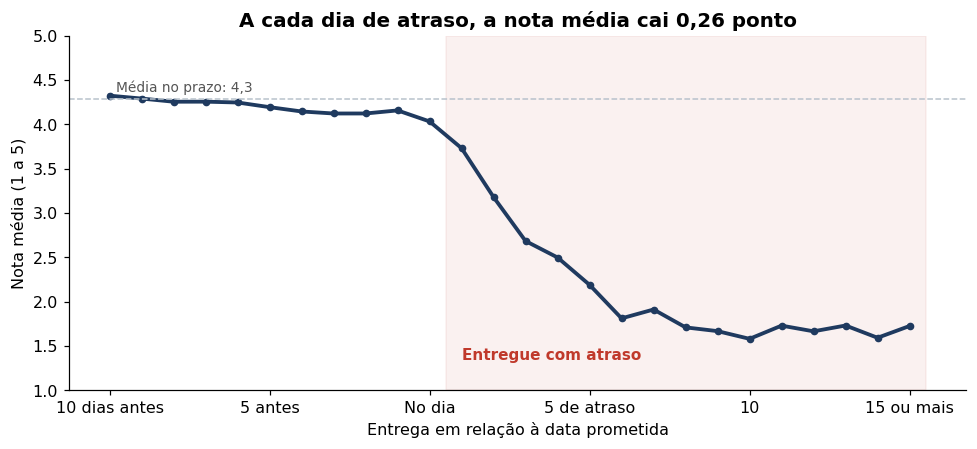

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axvspan(0.5, 15.5, color=VERMELHO, alpha=0.07)
ax.plot(curva.index, curva.values, color=AZUL, lw=2.5, marker='o', ms=4)
ax.axhline(nota_prazo, color=CINZA, ls='--', lw=1)
ax.text(-9.8, nota_prazo + 0.08, f'Média no prazo: {nota_prazo:.1f}'.replace('.', ','), color='#555', fontsize=9)
ax.text(1, 1.35, 'Entregue com atraso', color=VERMELHO, fontsize=10, fontweight='bold')
ax.set_xticks([-10, -5, 0, 5, 10, 15]); ax.set_xticklabels(['10 dias antes', '5 antes', 'No dia', '5 de atraso', '10', '15 ou mais'])
ax.set_ylim(1, 5); ax.set_ylabel('Nota média (1 a 5)'); ax.set_xlabel('Entrega em relação à data prometida')
ax.set_title(f'A cada dia de atraso, a nota média cai {queda_por_dia:.2f} ponto'.replace('.', ','))
plt.tight_layout(); plt.savefig('figuras/h1_atraso_nota.png', dpi=200); plt.show()

**Número:** a cada dia de atraso, a nota média cai **0,26 ponto**. No prazo, a nota média é **4,3**; com atraso, **2,3**. Entre os pedidos atrasados, **62%** recebem nota 1 ou 2, contra **9%** dos entregues no prazo.

**Conclusão (hipótese confirmada):** o prazo é o principal motor da insatisfação. Poucos dias de atraso já transformam um cliente satisfeito em detrator.

## Hipótese 2 — O frete pesa mais para clientes do Norte e Nordeste

**Pergunta do CEO:** onde perdemos dinheiro?  
**Como testamos:** calculamos quanto o frete representa, em média, no valor de cada pedido por região do cliente, e verificamos de onde saem os produtos vendidos.

In [4]:
peso_regiao = entregues.groupby('regiao').peso_frete.mean().sort_values()
itens_ent = bi[bi.order_status == 'delivered']
origem = itens_ent.regiao_vendedor.value_counts(normalize=True)
frete_estado = itens_ent.groupby('mesmo_estado').peso_frete.mean()

print('Peso médio do frete no pedido, por região do cliente:'); print((peso_regiao * 100).round(1).astype(str) + '%')
print(f'\nItens vendidos por vendedores do Sudeste: {origem["Sudeste"]:.0%}')
print(f'Frete no mesmo estado: {frete_estado[True]:.0%} | em outro estado: {frete_estado[False]:.0%}')

Peso médio do frete no pedido, por região do cliente:
regiao
Sudeste         19.5%
Sul             22.3%
Centro-Oeste    22.7%
Nordeste        26.3%
Norte           28.4%
Name: peso_frete, dtype: str

Itens vendidos por vendedores do Sudeste: 84%
Frete no mesmo estado: 18% | em outro estado: 23%


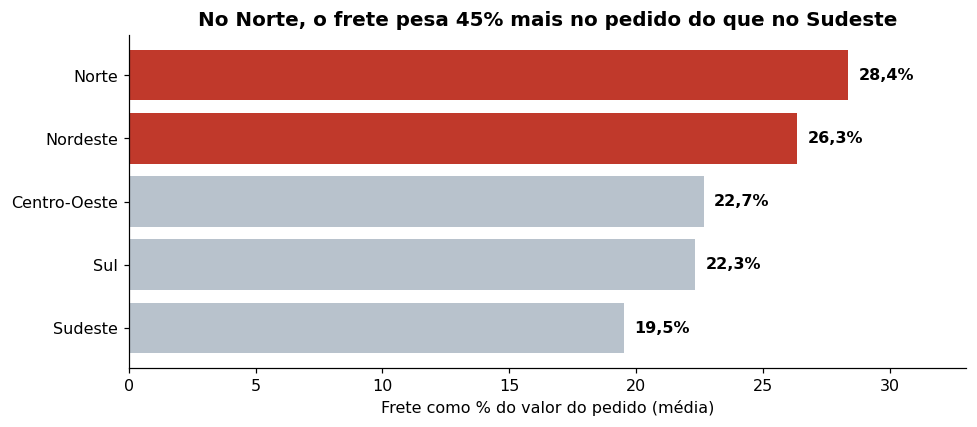

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
cores = [VERMELHO if r in ('Norte', 'Nordeste') else CINZA for r in peso_regiao.index]
barras = ax.barh(peso_regiao.index, peso_regiao.values * 100, color=cores)
for b, v in zip(barras, peso_regiao.values):
    ax.text(v * 100 + 0.4, b.get_y() + b.get_height() / 2, f'{v*100:.1f}%'.replace('.', ','), va='center', fontweight='bold')
ax.set_xlabel('Frete como % do valor do pedido (média)'); ax.set_xlim(0, 33)
n, s = peso_regiao['Norte'], peso_regiao['Sudeste']
ax.set_title(f'No Norte, o frete pesa {n/s-1:.0%} mais no pedido do que no Sudeste')
plt.tight_layout(); plt.savefig('figuras/h2_frete_regiao.png', dpi=200); plt.show()

**Número:** o frete representa em média **28%** do valor do pedido no Norte e **26%** no Nordeste, contra **19,5%** no Sudeste. **84%** dos itens vendidos saem de vendedores do Sudeste, e comprar de outro estado eleva o peso do frete de **18%** para **23%**.

**Conclusão (hipótese confirmada):** a concentração de vendedores no Sudeste encarece a compra nas regiões distantes e limita o crescimento fora do eixo principal.

## Hipótese 3 — O pagamento parcelado se concentra nos pedidos de valor alto

**Pergunta do CEO:** onde investir?  
**Como testamos:** entre os pedidos pagos com cartão de crédito, comparamos a proporção de compras parceladas e o número médio de parcelas por faixa de valor.

In [6]:
cartao = entregues[entregues.forma_pagamento == 'credit_card'].copy()
rotulos = ['Até R$ 50', 'R$ 50 a 100', 'R$ 100 a 200', 'R$ 200 a 500', 'Acima de R$ 500']
cartao['faixa'] = pd.cut(cartao.receita_bruta, [0, 50, 100, 200, 500, np.inf], labels=rotulos)
parc = cartao.groupby('faixa', observed=True).agg(
    pct_parcelado=('parcelas', lambda x: (x > 1).mean()),
    media_parcelas=('parcelas', 'mean'),
    pedidos=('order_id', 'count'))
parc.style.format({'pct_parcelado': '{:.0%}', 'media_parcelas': '{:.1f}', 'pedidos': '{:,}'})

,pct_parcelado,media_parcelas,pedidos
faixa,,,
Até R$ 50,40%,1.7,"11,448"
R$ 50 a 100,57%,2.7,"21,571"
R$ 100 a 200,78%,3.8,"23,896"
R$ 200 a 500,87%,5.2,"12,378"
Acima de R$ 500,92%,7.2,"3,319"


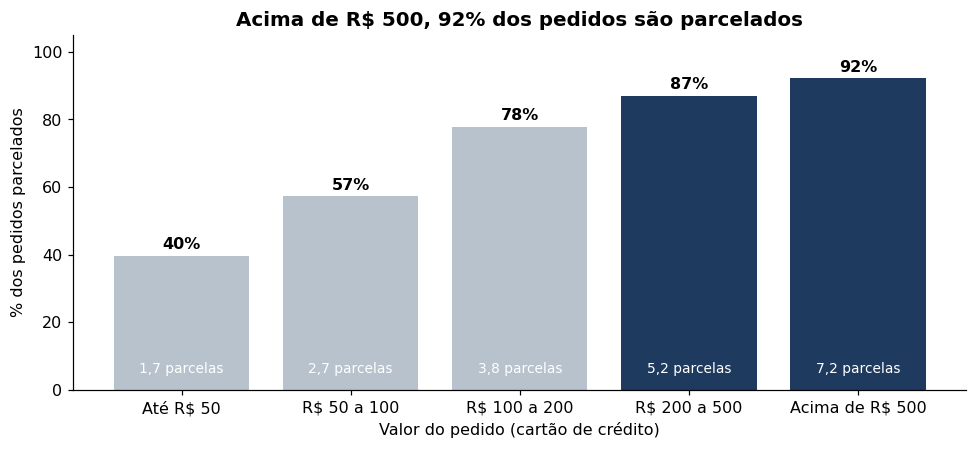

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
cores = [AZUL if i >= 3 else CINZA for i in range(len(parc))]
barras = ax.bar(parc.index.astype(str), parc.pct_parcelado * 100, color=cores)
for b, p, m in zip(barras, parc.pct_parcelado, parc.media_parcelas):
    ax.text(b.get_x() + b.get_width() / 2, p * 100 + 2, f'{p:.0%}', ha='center', fontweight='bold')
    ax.text(b.get_x() + b.get_width() / 2, 5, f'{m:.1f} parcelas'.replace('.', ','), ha='center', color='white', fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel('% dos pedidos parcelados'); ax.set_xlabel('Valor do pedido (cartão de crédito)')
ax.set_title(f'Acima de R$ 500, {parc.pct_parcelado.iloc[-1]:.0%} dos pedidos são parcelados')
plt.tight_layout(); plt.savefig('figuras/h3_parcelamento_ticket.png', dpi=200); plt.show()

**Número:** em compras de até R$ 50, **40%** são parceladas, com média de 1,7 parcela. Acima de R$ 500, **92%** são parceladas, com média de **7 parcelas**.

**Conclusão (hipótese confirmada):** o parcelamento é o que viabiliza as vendas de maior valor. Condições de pagamento são uma alavanca direta de ticket médio.

## Hipótese extra — O Nordeste cresce mais rápido que o Sudeste (refutada)

**Como testamos:** comparamos a receita de janeiro a agosto de 2017 com o mesmo período de 2018, por região do cliente.

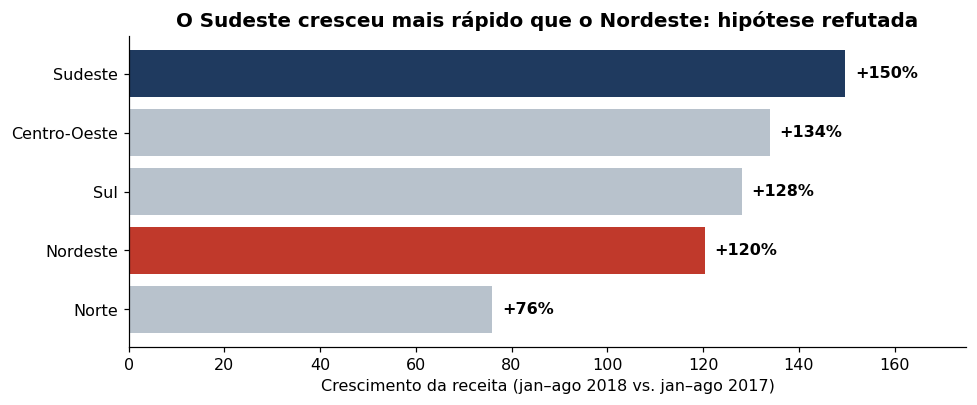

In [8]:
bp['ano'] = bp.order_purchase_timestamp.dt.year
bp['mes'] = bp.order_purchase_timestamp.dt.month
cresc = bp[bp.mes <= 8].groupby(['regiao', 'ano']).receita_bruta.sum().unstack()
cresc['crescimento'] = cresc[2018] / cresc[2017] - 1
cresc = cresc.sort_values('crescimento')

fig, ax = plt.subplots(figsize=(9, 3.8))
cores = [AZUL if r == 'Sudeste' else (VERMELHO if r == 'Nordeste' else CINZA) for r in cresc.index]
barras = ax.barh(cresc.index, cresc.crescimento * 100, color=cores)
for b, v in zip(barras, cresc.crescimento):
    ax.text(v * 100 + 2, b.get_y() + b.get_height() / 2, f'+{v:.0%}', va='center', fontweight='bold')
ax.set_xlabel('Crescimento da receita (jan–ago 2018 vs. jan–ago 2017)'); ax.set_xlim(0, 175)
ax.set_title('O Sudeste cresceu mais rápido que o Nordeste: hipótese refutada')
plt.tight_layout(); plt.savefig('figuras/extra_crescimento_regiao.png', dpi=200); plt.show()

**Número:** entre 2017 e 2018, a receita do Sudeste cresceu **150%** e a do Nordeste, **120%**.

**Conclusão (hipótese refutada):** o crescimento acompanhou a concentração existente, e não o contrário. Isso reforça a Hipótese 2: sem vendedores próximos, as regiões distantes crescem menos.

## Síntese para os próximos entregáveis

| Hipótese | Resultado | Número-chave |
|---|---|---|
| 1. Atraso derruba a nota | Confirmada | −0,26 ponto na nota por dia de atraso |
| 2. Frete pesa mais no Norte e Nordeste | Confirmada | Frete = 28% do pedido no Norte vs. 19,5% no Sudeste |
| 3. Parcelamento se concentra em ticket alto | Confirmada | 92% parcelam acima de R$ 500 (7 parcelas em média) |
| Extra. Nordeste cresce mais rápido | Refutada | Sudeste +150% vs. Nordeste +120% |

**Cuidado de interpretação:** as análises mostram associação entre fatores, não provam causa e efeito. As recomendações do board devem ser tratadas como hipóteses de ação a serem testadas.